In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
%matplotlib inline

In [2]:
movies= pd.read_csv('movies_updated.csv')
movies.head(3)

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,"runtime,,"
0,The Shining,R,Drama,1980,"June 13, 1980 (United States)",8.4,927000,Stanley Kubrick,Stephen King,Jack Nicholson,United Kingdom,19000000,46998772.0,Warner Bros.,"146.0,"
1,The Blue Lagoon,R,Adventure,1980,"July 2, 1980 (United States)",5.8,65000,Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,United States,4500000,58853106.0,Columbia Pictures,"104.0,"
2,Star Wars: Episode V - The Empire Strikes Back,PG,Action,1980,"June 20, 1980 (United States)",8.7,1200000,Irvin Kershner,Leigh Brackett,Mark Hamill,United States,18000000,538375067.0,Lucasfilm,"124.0,"


### Exercise 1

#### Task 0: Analyze and Clean Dataset 

In [3]:
movies.isna().sum()
(movies['budget'] == 0).sum()

np.int64(1392)

Before creating the ROI 
* the datset contains movies with a blank(nan) value
* the dataset contains 1,392 movies with a budget of 0.

#### Task 1: Clean Missing values 

In [4]:
movies = movies.dropna(subset=['rating', 'writer', 'star','gross', 'company' ])
movies = movies[movies['budget'] > 0]
movies

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,"runtime,,"
0,The Shining,R,Drama,1980,"June 13, 1980 (United States)",8.4,927000,Stanley Kubrick,Stephen King,Jack Nicholson,United Kingdom,19000000,46998772.0,Warner Bros.,"146.0,"
1,The Blue Lagoon,R,Adventure,1980,"July 2, 1980 (United States)",5.8,65000,Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,United States,4500000,58853106.0,Columbia Pictures,"104.0,"
2,Star Wars: Episode V - The Empire Strikes Back,PG,Action,1980,"June 20, 1980 (United States)",8.7,1200000,Irvin Kershner,Leigh Brackett,Mark Hamill,United States,18000000,538375067.0,Lucasfilm,"124.0,"
3,Airplane!,PG,Comedy,1980,"July 2, 1980 (United States)",7.7,221000,Jim Abrahams,Jim Abrahams,Robert Hays,United States,3500000,83453539.0,Paramount Pictures,"88.0,"
4,Caddyshack,R,Comedy,1980,"July 25, 1980 (United States)",7.3,108000,Harold Ramis,Brian Doyle-Murray,Chevy Chase,United States,6000000,39846344.0,Orion Pictures,"98.0,"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3994,O,R,Drama,2001,"August 31, 2001 (United States)",6.1,19000,Tim Blake Nelson,William Shakespeare,Mekhi Phifer,United States,5000000,19260537.0,Chickie the Cop,"95.0,"
3995,Birthday Girl,R,Comedy,2001,"February 1, 2002 (United States)",6.1,25000,Jez Butterworth,Tom Butterworth,Nicole Kidman,United Kingdom,13000000,16171098.0,FilmFour,"93.0,"
3997,Made,R,Comedy,2001,"August 31, 2001 (United States)",6.4,18000,Jon Favreau,Jon Favreau,Vince Vaughn,United States,5000000,5480653.0,Artisan Entertainment,"95.0,"
3998,One Night at McCool's,R,Comedy,2001,"April 27, 2001 (United States)",6.1,29000,Harald Zwart,Stan Seidel,Liv Tyler,United States,18000000,13578186.0,October Films,"93.0,"


#### Task 2: Calculate ROI 

In [5]:
movies['roi'] = (( movies['gross'] - movies['budget'] ) / movies['budget']).round(2)
movies.head(3)

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,"runtime,,",roi
0,The Shining,R,Drama,1980,"June 13, 1980 (United States)",8.4,927000,Stanley Kubrick,Stephen King,Jack Nicholson,United Kingdom,19000000,46998772.0,Warner Bros.,"146.0,",1.47
1,The Blue Lagoon,R,Adventure,1980,"July 2, 1980 (United States)",5.8,65000,Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,United States,4500000,58853106.0,Columbia Pictures,"104.0,",12.08
2,Star Wars: Episode V - The Empire Strikes Back,PG,Action,1980,"June 20, 1980 (United States)",8.7,1200000,Irvin Kershner,Leigh Brackett,Mark Hamill,United States,18000000,538375067.0,Lucasfilm,"124.0,",28.91


#### Task 3: Budget Vs. Gross Scatter Plot 

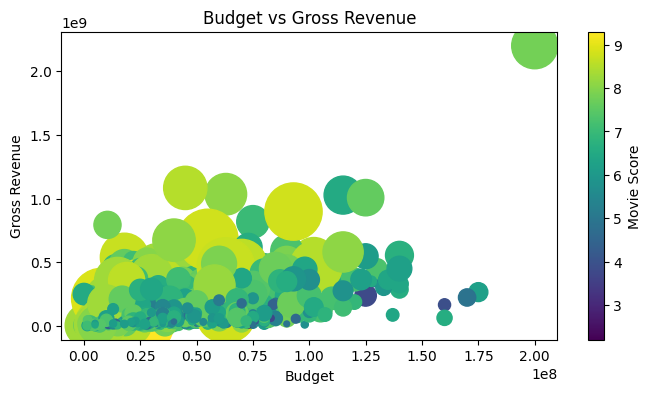

In [124]:
fig, ax = plt.subplots(figsize=(8,4))

scatter = ax.scatter(movies['budget'], movies['gross'], s=movies['votes']/1000, c=movies['score'])
plt.colorbar(scatter,label='Movie Score')

ax.set(title='Budget vs Gross Revenue', xlabel='Budget', ylabel='Gross Revenue');

#### Task 4: Top Movies with the Highest ROI

In [18]:
top_roi_movies = movies[['name', 'roi']].sort_values(by= 'roi',ascending=False).head(10)
top_roi_movies

,name,roi
3459,The Blair Witch Project,4142.98
2093,El Mariachi,290.56
2467,Clerks,115.71
3233,In the Company of Men,111.18
209,E.T. the Extra-Terrestrial,74.52
3089,The Full Monty,72.70
5,Friday the 13th,71.28
2458,Four Weddings and a Funeral,54.84
3291,Pi,52.69
1684,Slacker,52.40


#### Task 5: RIO Distribution Across Top Genres

In [53]:
top_genre = movies['genre'].value_counts().index
df_top = movies[movies['genre'].isin(top_genre)]

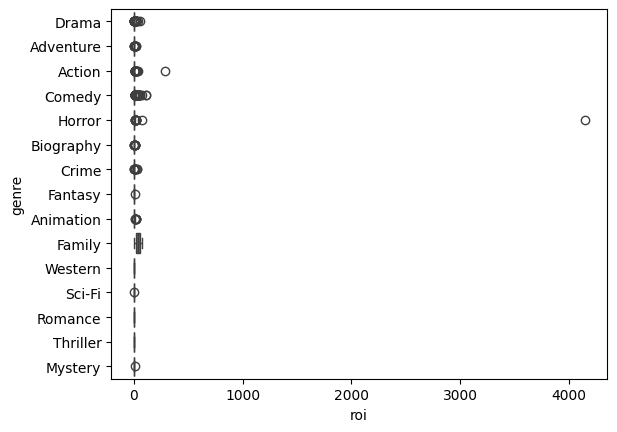

In [55]:
sns.set_theme
sns.boxplot(
    data=df_top,
    x='roi',
    y='genre'
);

Based on the visuals we can conclude
* large Budget has a positive relation with high revenue. Movies with large Budget generally tend to get larger gross but it doesnt guarentte higher revenue.
* A Horror movie surprisingly has the highest RIO
* While some highly rated films generate strong revenues, they are not always financially successful.  

### Exercise 2 

#### Task 1 & 2

In [136]:
director_stats = (movies.groupby('director').agg(
        Number_of_Movies=('score', 'count'),
        Average_Score=('score', 'mean'),
        Median_Score=('score', 'median'),
        Std_Deviation=('score', 'std')
    )
)
director_stats = director_stats[
    director_stats['Number_of_Movies'] >= 5
]

director_stats.sort_values('Std_Deviation').head()

,Number_of_Movies,Average_Score,Median_Score,Std_Deviation
director,,,,
Jim Jarmusch,5,7.620000,7.60,0.083666
Steve Miner,6,5.950000,5.95,0.242899
Paul Mazursky,6,6.283333,6.35,0.292689
Joel Coen,9,7.655556,7.70,0.308671
Michael Caton-Jones,5,6.580000,6.50,0.311448


#### Task 3: Directors Visualization

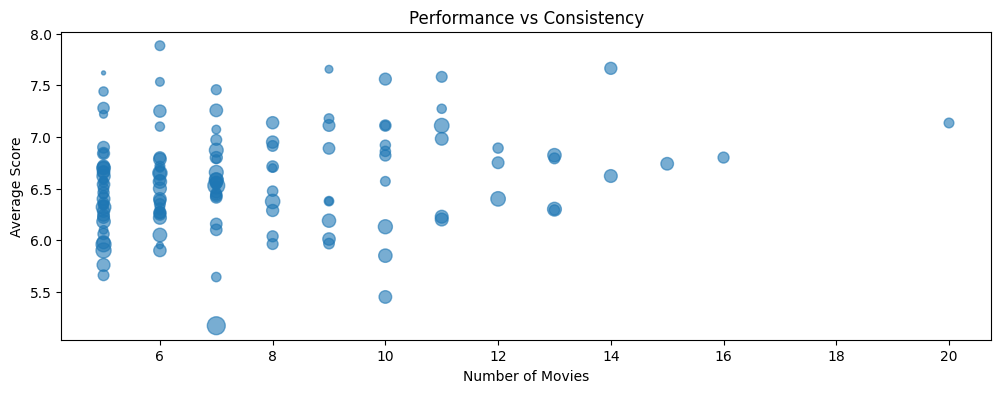

In [134]:
fig, ax = plt.subplots(figsize=(12,4))

ax.scatter(
    director_stats['Number_of_Movies'],
    director_stats['Average_Score'],
    s=director_stats['Std_Deviation']* 100,
    alpha=0.6
)

ax.set(title='Performance vs Consistency', xlabel='Number of Movies', ylabel='Average Score');

#### Task 4: Company Status 

In [139]:
company_stats = (movies.groupby('company').agg(
        Average_Gross_Revenue=('gross','mean'),
        Average_ROI=('roi','mean'),
        Average_Score=('score','mean'),
        Number_of_Movies=('score','count')
    )
)

company_stats = company_stats[
    company_stats['Number_of_Movies'] >= 20
]

company_stats.sort_values('Average_Score',ascending=False).head()

,Average_Gross_Revenue,Average_ROI,Average_Score,Number_of_Movies
company,,,,
Miramax,4.987588e+07,3.018857,6.648571,35
Castle Rock Entertainment,4.618047e+07,0.485000,6.582353,34
Touchstone Pictures,9.715339e+07,2.370909,6.542424,66
Walt Disney Pictures,1.811705e+08,4.091471,6.523529,34
Universal Pictures,1.028606e+08,2.969603,6.406623,151


Based on the analysis we can conclude
* consistent directors: Jim Jarmusch, Steve Miner, Paul Mazursky
* quality over profitability companies :  Miramax, Castle Rock, Touchstone
* profitability over quality companies : Disney, 20th Century, Universal

### Exercise 3

#### Task 1: Create a decade column

In [146]:
movies['decade'] = (movies['year'] // 10) * 10

#### Task 2: decade genre status 

In [156]:
genre_decade = (movies.groupby(['decade','genre']).agg(
        movie_count=('name','count'),
        avg_score=('score','mean'),
        total_gross=('gross','sum')
    )
    .reset_index()
)
genre_decade

,decade,genre,movie_count,avg_score,total_gross
0,1980,Action,222,6.193243,1.083790e+10
1,1980,Adventure,72,6.156944,2.502041e+09
2,1980,Animation,18,7.072222,9.438790e+08
3,1980,Biography,32,7.131250,1.158281e+09
4,1980,Comedy,278,6.266187,8.896916e+09
5,1980,Crime,60,6.646667,1.049496e+09
6,1980,Drama,124,6.559677,3.676726e+09
7,1980,Family,1,7.800000,7.929106e+08
8,1980,Fantasy,14,6.185714,2.848261e+08
9,1980,Horror,60,6.025000,8.700108e+08


#### Task 3: Genre Popularity evolvement 

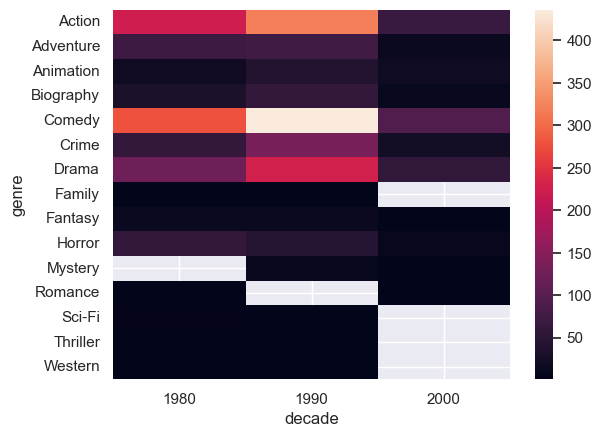

In [158]:
pivot = genre_decade.pivot(
    index='genre',
    columns='decade',
    values='movie_count'
)

sns.heatmap(pivot);

#### Task 4&5 : Country_Status

In [161]:
country_stats = (
    movies.groupby('country')
    .agg(
        Average_Score=('score','mean'),
        Average_Budget=('budget','mean'),
        Average_Gross=('gross','mean'),
        Average_ROI=('roi','mean'),
        Number_of_Movies=('score','count')
    )
)

country_stats = country_stats[
    country_stats['Number_of_Movies'] >= 30
]
country_stats

,Average_Score,Average_Budget,Average_Gross,Average_ROI,Number_of_Movies
country,,,,,
Canada,5.868182,1.378130e+07,1.641894e+07,3.821364,44
France,6.653488,2.969767e+07,3.671473e+07,0.396512,43
United Kingdom,6.516176,1.956051e+07,3.610853e+07,1.412353,204
United States,6.322571,2.490783e+07,6.191266e+07,4.032514,2100


#### Task 6: Country Visuals 

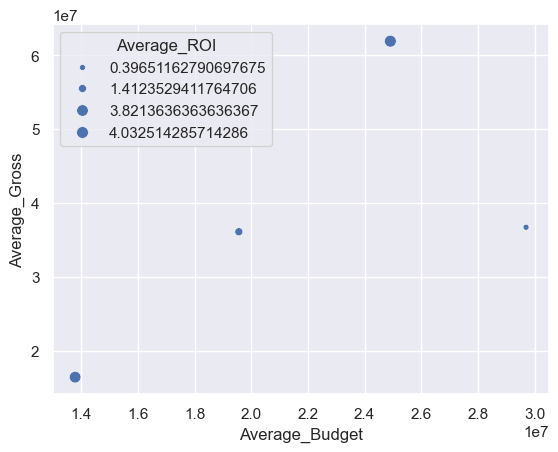

In [165]:
sns.scatterplot(
    data=country_stats,
    x='Average_Budget',
    y='Average_Gross',
    size='Average_ROI'
);

#### Task 7&8: Hidden Gems

In [176]:
movies['hidden_gem'] = ((movies['score'] >= 8) & (movies['votes'] < movies['votes'].median()))
hidden_genre = (movies[movies['hidden_gem']].groupby('genre').size())
hidden_country = (movies[movies['hidden_gem']].groupby('country').size())
movies[movies['hidden_gem'] == True]

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,"runtime,,",roi,decade,hidden_gem
724,Mishima: A Life in Four Chapters,R,Biography,1985,"September 20, 1985 (United States)",8.0,10000,Paul Schrader,Paul Schrader,Ken Ogata,United States,5000000,569996.0,Zoetrope Studios,"120.0,",-0.89,1980,True
2625,Pred dozhdot,Not Rated,Drama,1994,"February 24, 1995 (United States)",8.0,14000,Milcho Manchevski,Milcho Manchevski,Katrin Cartlidge,Republic of Macedonia,1900000,763847.0,Aim,"113.0,",-0.60,1990,True


#### Task 9: VIusalization of Hidden Gems 

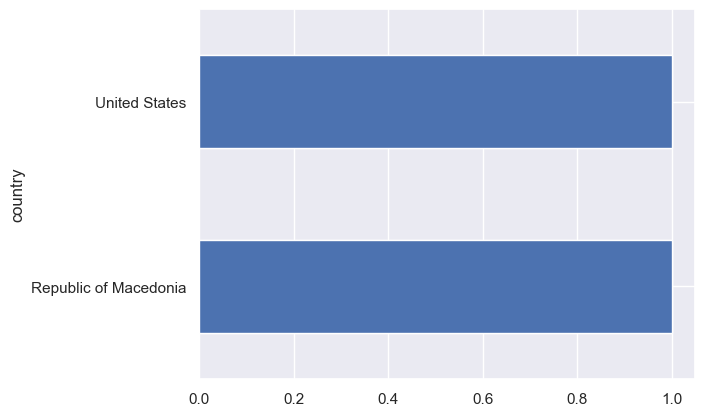

In [185]:
hidden_genre.plot.barh()
hidden_country.plot.barh();

Based on the Analysis we can conclude
* Scifi, Thriller, Family and Western gained popularity over the decade
*  UK produce the highest-quality movies relative to budget
*  Republic of macednoina appear to be the most underrated by audience 